# Тихонов илья

# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [63]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [64]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [65]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        return np.square(X.dot(w) - y).mean()

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        l = X.shape[0]
        return 2 * ((X.transpose() / l) @ (X.dot(w) - y))

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [66]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [67]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    gradient_descent_directions = list()
    w_prev = w_init
    for iteration in range(n_iterations):
        w_new = w_prev - lr * loss.calc_grad(X, y, w_prev)
        gradient_descent_directions.append(w_new)
        w_prev = w_new

    return gradient_descent_directions

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [68]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [69]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

155.2625821435192
0.8670644395649493


In [70]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

lr=0.0001


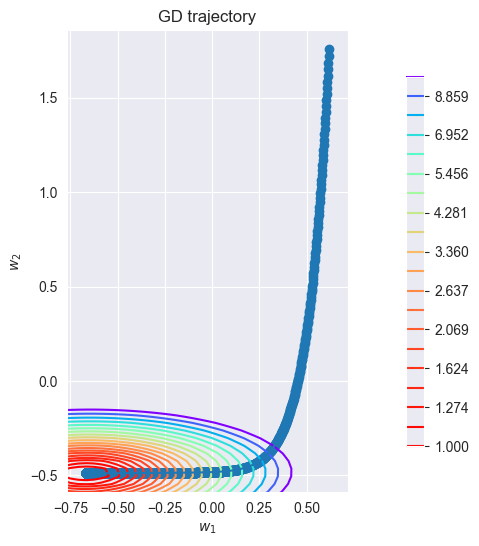

lr=0.001


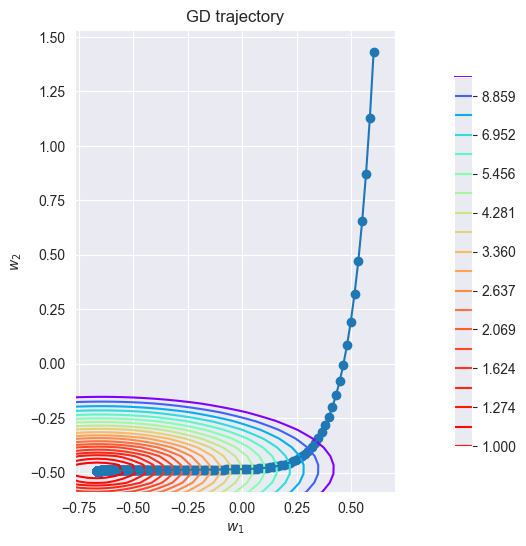

lr=0.005


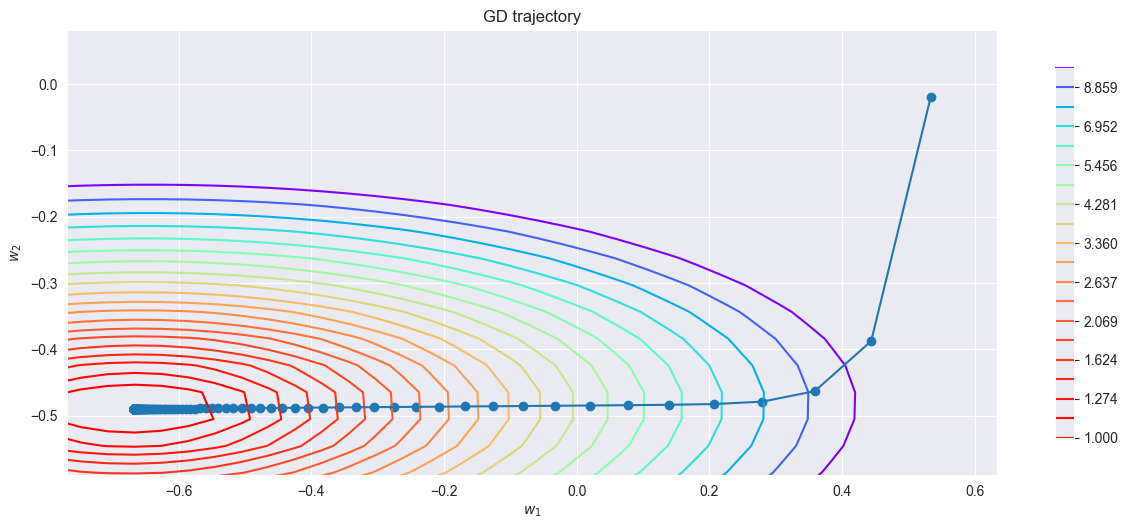

lr=0.01


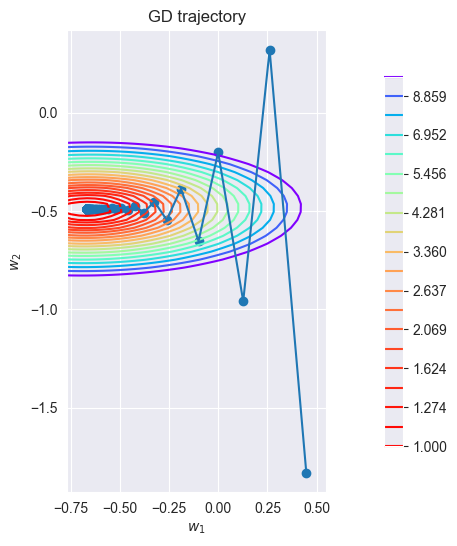

In [71]:
lrs = [0.0001, 0.001, 0.005, 0.01]

for lr in lrs:
    print(f"lr={lr}")
    w_list = gradient_descent(w_init, X, y, loss, lr, 10000)
    plot_gd(w_list, X, y, loss)


При маленьком `lr` градиентный спуск сходится очень медленно, потому что каждый шаг почти не меняет веса. При увеличении `lr` траектория быстрее приходит к минимуму, но слишком большой шаг начинает перескакивать через минимум и может привести к расходимости или переполнению.

In [72]:
lr = 0.1
w_list = gradient_descent(w_init, X, y, loss, lr, 20)
print(loss.calc_loss(X, y, w_list[-1]))


3.828927655094893e+49


Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [73]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    np.random.seed(653543)
    l = X.shape[0]

    gradient_descent_directions = list()
    w_prev = w_init
    for iteration in range(n_iterations):

        batch_indices = np.random.choice(l, size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        w_new = w_prev - lr * loss.calc_grad(X_batch, y_batch, w_prev)
        gradient_descent_directions.append(w_new)
        w_prev = w_new

    return gradient_descent_directions

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

lr=0.0001, batch_size=10


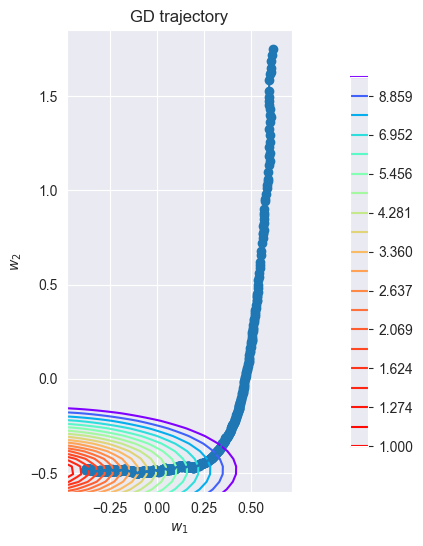

lr=0.0001, batch_size=50


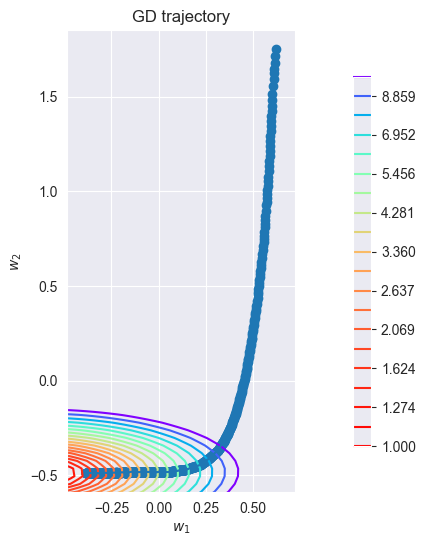

lr=0.0001, batch_size=100


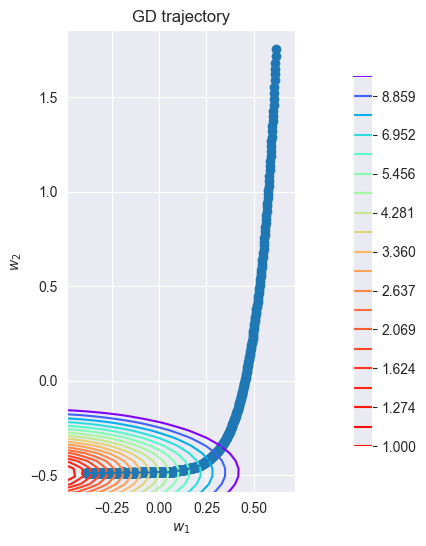

lr=0.0001, batch_size=150


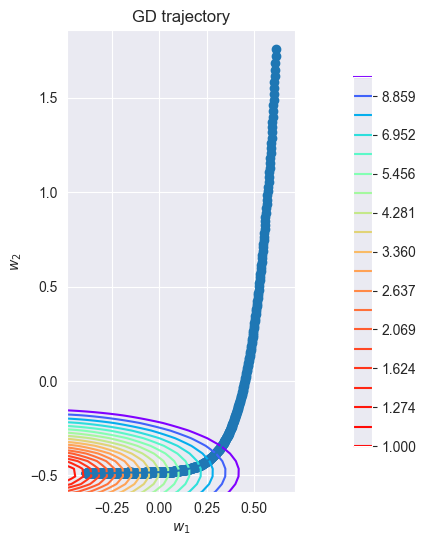

lr=0.001, batch_size=10


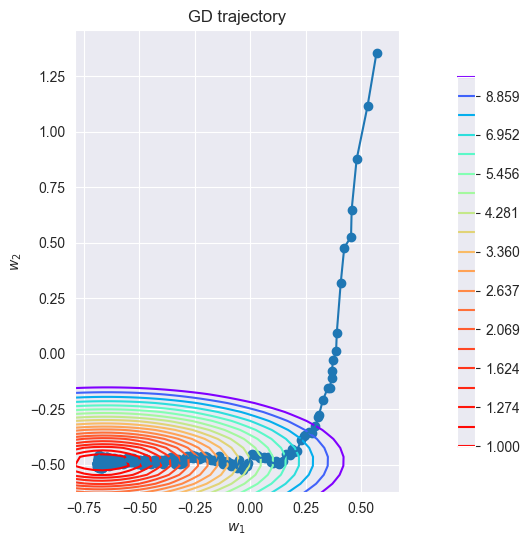

lr=0.001, batch_size=50


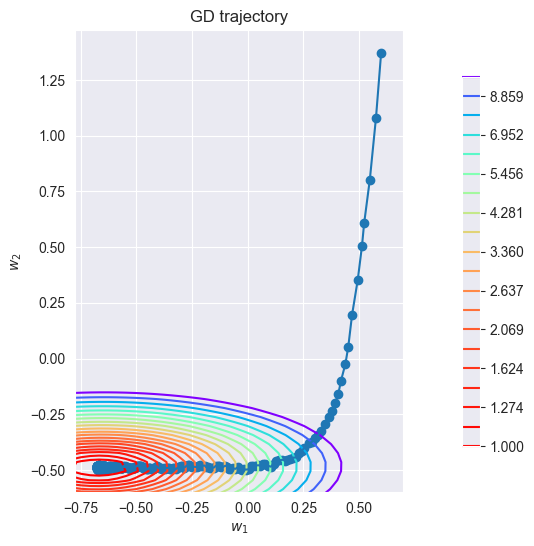

lr=0.001, batch_size=100


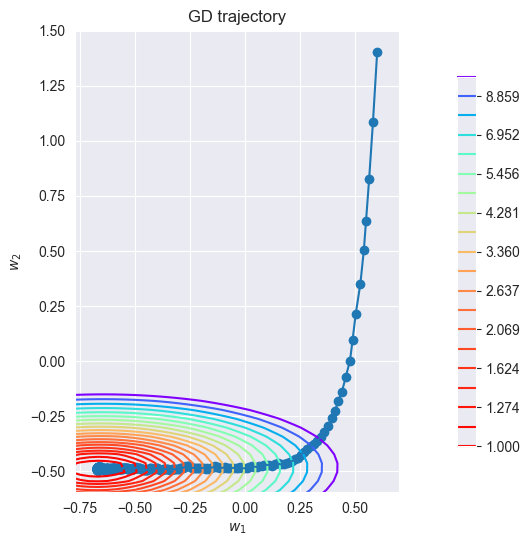

lr=0.001, batch_size=150


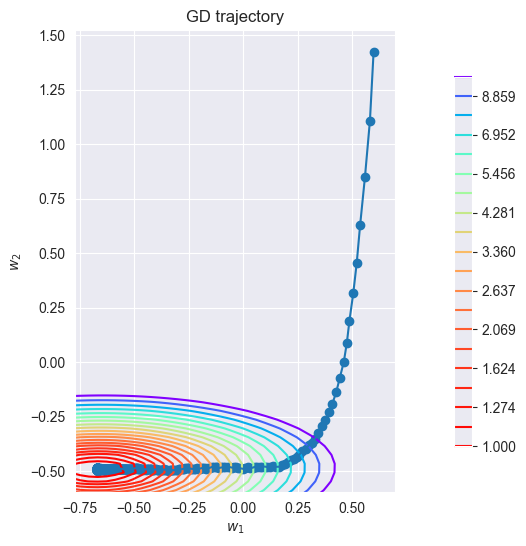

lr=0.005, batch_size=10


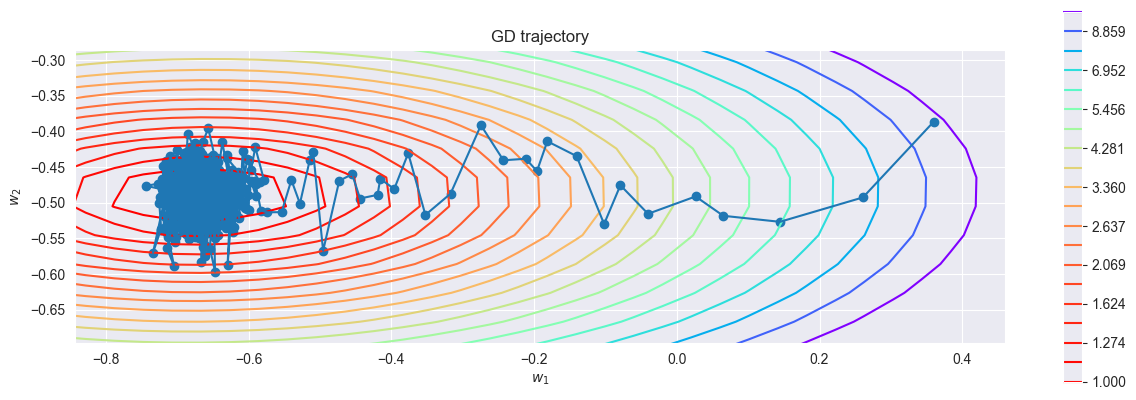

lr=0.005, batch_size=50


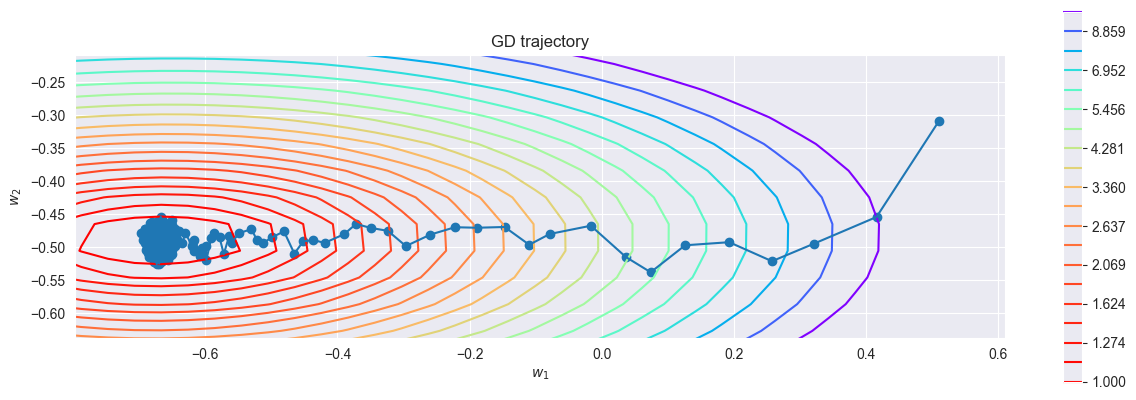

lr=0.005, batch_size=100


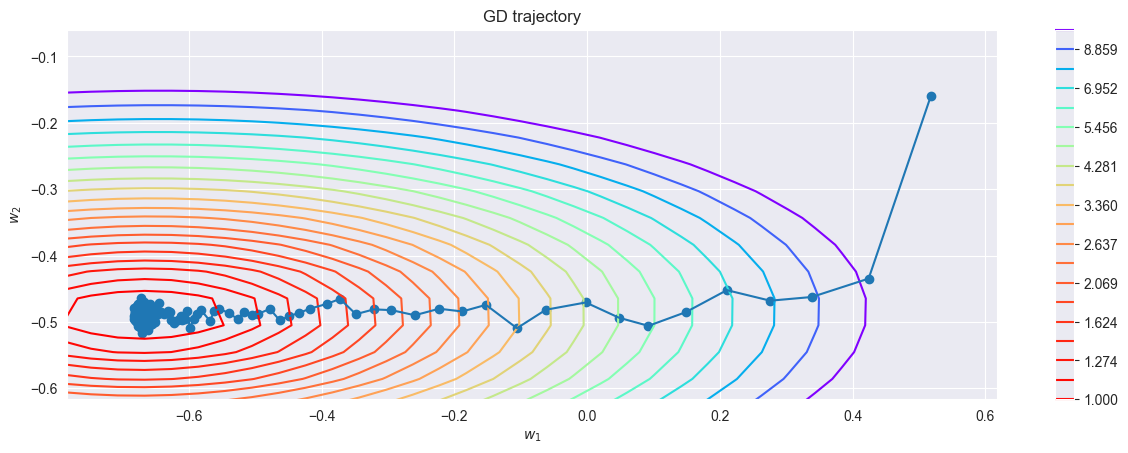

lr=0.005, batch_size=150


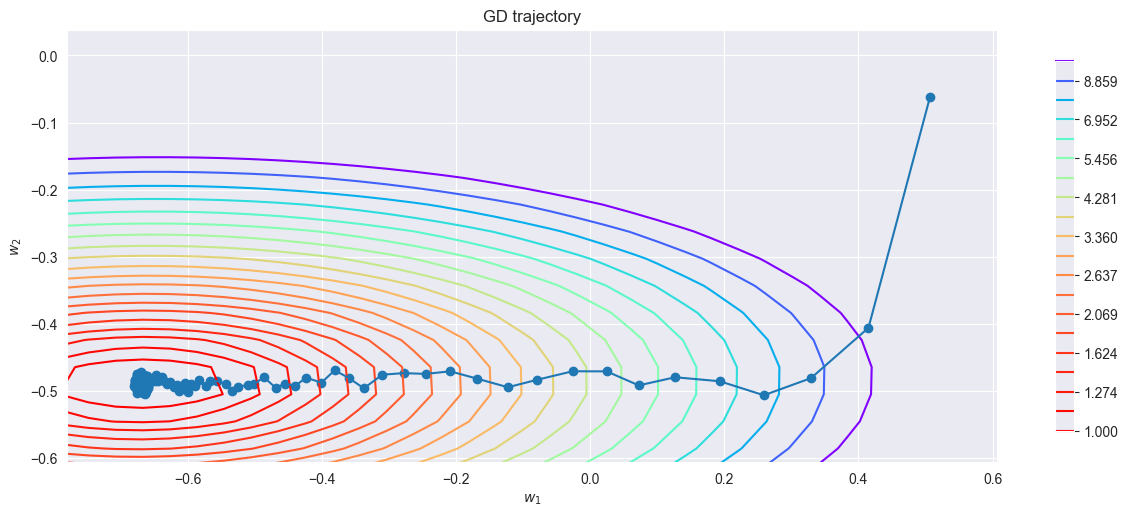

lr=0.01, batch_size=10


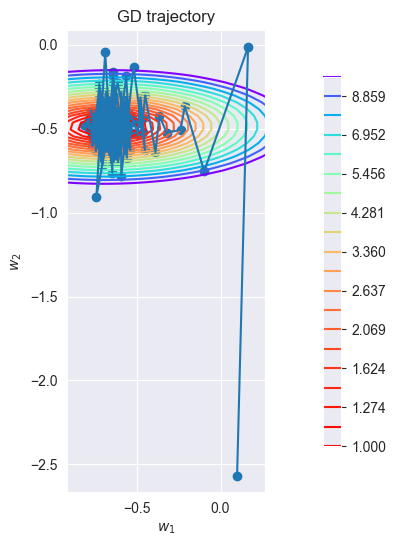

lr=0.01, batch_size=50


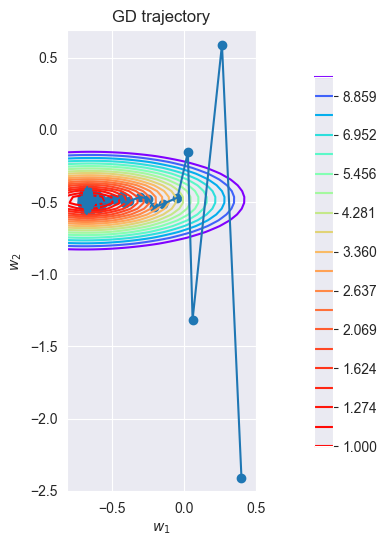

lr=0.01, batch_size=100


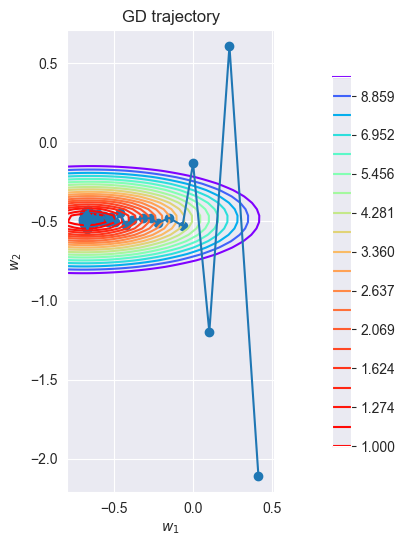

lr=0.01, batch_size=150


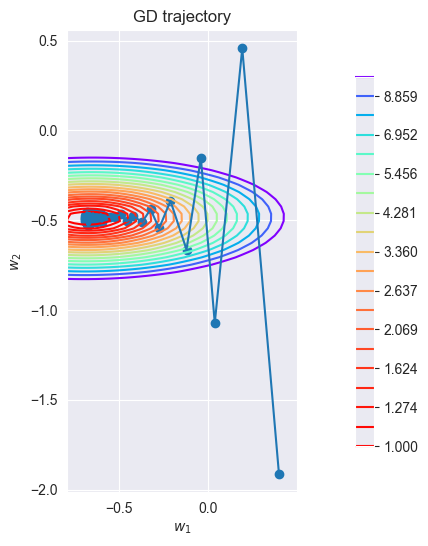

In [74]:
lrs = [0.0001, 0.001, 0.005, 0.01] # знаем что при lr = 0.1 не сходится, поэтому возьму 0.005
batch_sizes = [10, 50, 100, 150]

for lr in lrs:
    for batch_size in batch_sizes:
        print(f"lr={lr}, batch_size={batch_size}")
        w_list = stochastic_gradient_descent(w_init ,X, y, loss, lr, batch_size)
        plot_gd(w_list, X, y, loss)

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [75]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    np.random.seed(3424)
    l = X.shape[0]
    s0 = 1

    gradient_descent_directions = list()
    w_prev = w_init
    for iteration in range(n_iterations):
        batch_indices = np.random.choice(l, size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]
        n_t = lr * (s0 / (s0 + iteration)) ** p

        w_new = w_prev - n_t * loss.calc_grad(X_batch, y_batch, w_prev)
        gradient_descent_directions.append(w_new)
        w_prev = w_new

    return gradient_descent_directions

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

p = 0.1


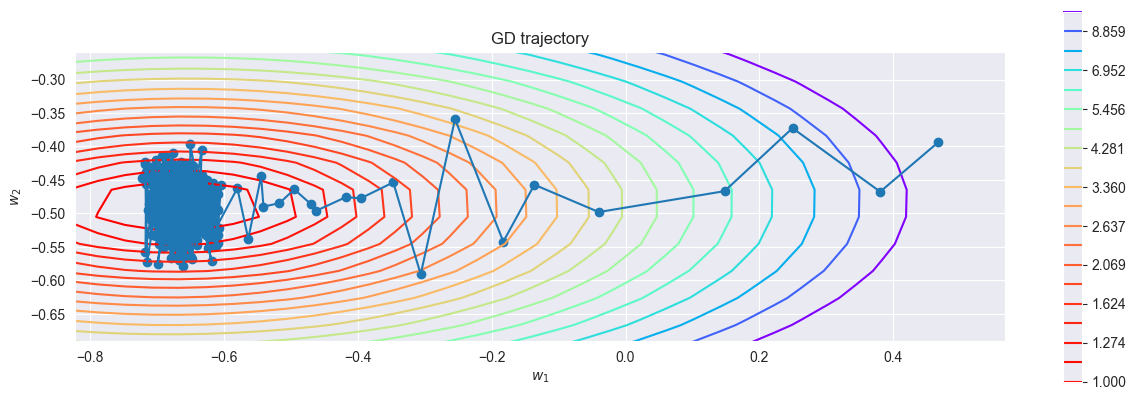

p = 0.3


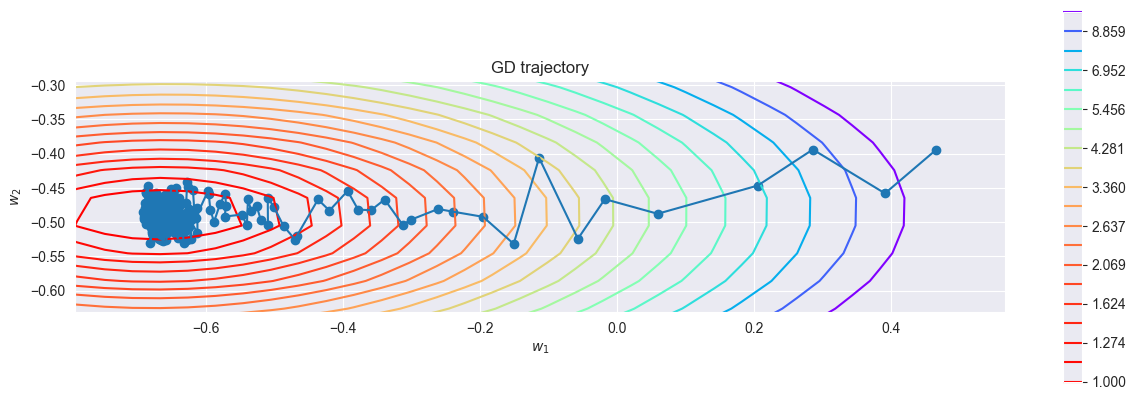

p = 0.7


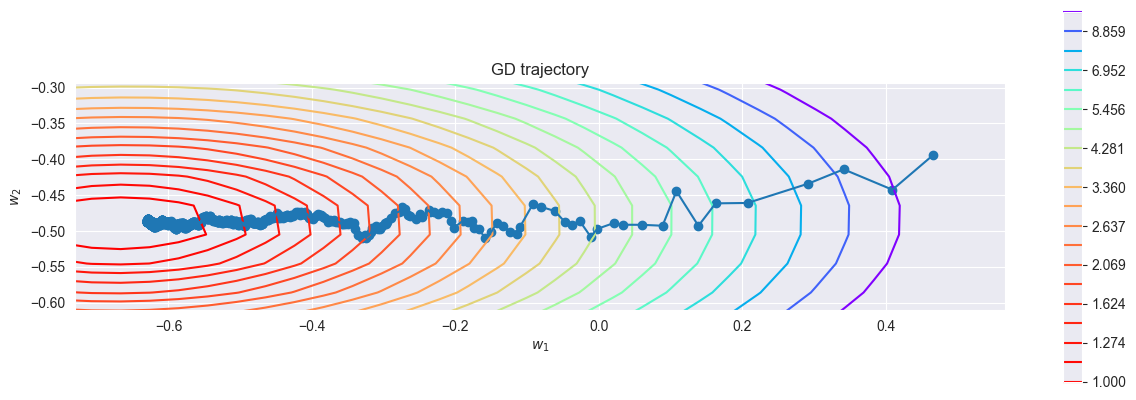

p = 1


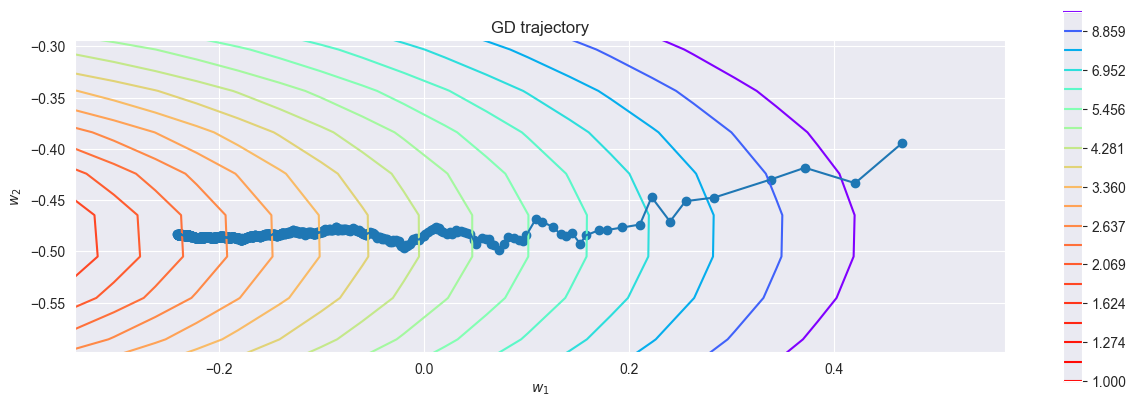

In [76]:
lr = 0.01
batch_size = 10
ps = [0.1, 0.3, 0.7, 1]

for p in ps:
    print(f'p = {p}')
    w_list = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p)
    plot_gd(w_list, X, y, loss)

По графику видно, что при маленьком `p` шаг затухает медленно: SGD быстрее подходит к окрестности минимума, но дольше шумит около него. При большом `p` шаг быстро становится маленьким, поэтому траектория получается более спокойной, но может не успеть дойти до минимума за фиксированное число итераций. При `p=1` в этом запуске спуск за 1000 итераций еще не успевает нормально сойтись.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

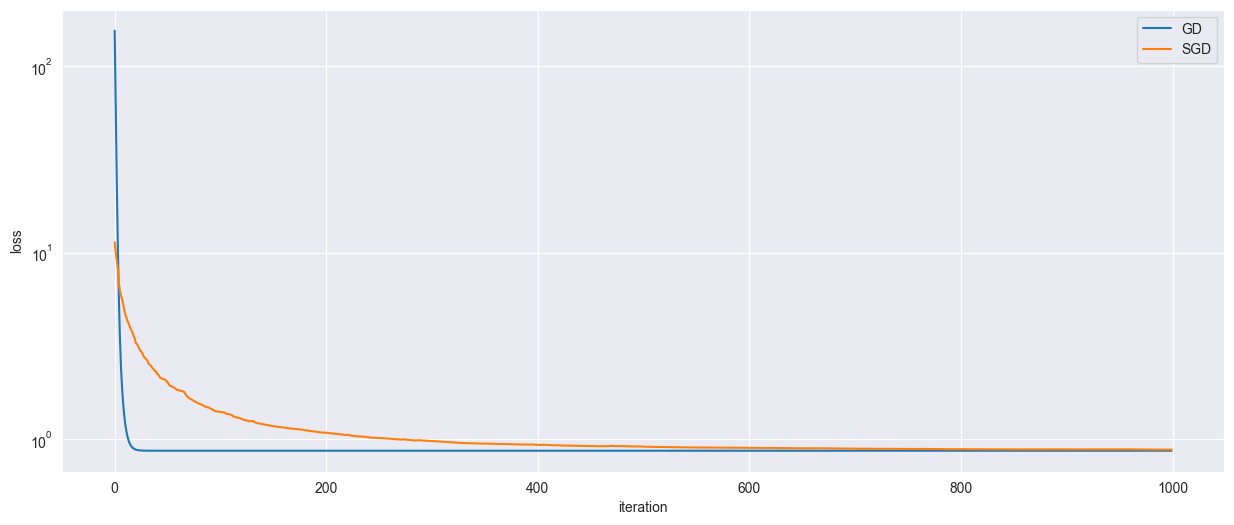

GD final loss: 0.8671
SGD final loss: 0.8791


In [77]:
lr = 0.01
batch_size = 10
p = 0.7
n_iterations = 1000

gd_w_list = gradient_descent(w_init, X, y, loss, lr, n_iterations)
sgd_w_list = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p, n_iterations)

gd_loss = [loss.calc_loss(X, y, w) for w in gd_w_list]
sgd_loss = [loss.calc_loss(X, y, w) for w in sgd_w_list]

plt.figure(figsize=(15, 6))
plt.plot(gd_loss, label="GD")
plt.plot(sgd_loss, label="SGD")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")
plt.legend()
plt.show()

print(f"GD final loss: {gd_loss[-1]:.4f}")
print(f"SGD final loss: {sgd_loss[-1]:.4f}")


На графике видно, что обычный GD убывает более гладко, а SGD идет шумнее из-за случайных батчей. Преимущество SGD в том, что одна итерация дешевле на больших данных, поэтому за одинаковое время он может сделать больше шагов, хотя по номеру итерации его кривая менее стабильна.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [78]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        w_init = np.zeros(X.shape[1])
        self.w = gradient_descent(w_init, X, y, self.loss, self.lr, 1000)[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X.dot(self.w)


Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [79]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [80]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [81]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [82]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

train, test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=27,
)

numeric_features = X_raw.select_dtypes(include=np.number).columns
categorical_features = X_raw.select_dtypes(exclude=np.number).columns

num_imputer = SimpleImputer(strategy="median")
train_num = num_imputer.fit_transform(train[numeric_features])
test_num = num_imputer.transform(test[numeric_features])

scaler = StandardScaler()
train_num = scaler.fit_transform(train_num)
test_num = scaler.transform(test_num)


In [83]:
from sklearn.preprocessing import OneHotEncoder

cat_imputer = SimpleImputer(strategy="most_frequent")
train_cat = cat_imputer.fit_transform(train[categorical_features])
test_cat = cat_imputer.transform(test[categorical_features])

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
train_cat = encoder.fit_transform(train_cat)
test_cat = encoder.transform(test_cat)

X_train = np.hstack([train_num, train_cat])
X_test = np.hstack([test_num, test_cat])
y_train = y_train.to_numpy(dtype=float)
y_test = y_test.to_numpy(dtype=float)

print(X_train.shape, X_test.shape)


(160, 74) (41, 74)


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [84]:
linear_regression = LinearRegression(MSELoss(), lr=0.1)
linear_regression.fit(X_train, y_train)


**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [85]:
from sklearn.metrics import mean_squared_error

train_pred = linear_regression.predict(X_train)
test_pred = linear_regression.predict(X_test)

mse_train = mean_squared_error(y_train, train_pred)
mse_test = mean_squared_error(y_test, test_pred)

print(f"MSE train: {mse_train:.2f}")
print(f"MSE test: {mse_test:.2f}")


MSE train: 2085658.58
MSE test: 4015051.08


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [86]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        regularized_w = w.copy()
        regularized_w[-1] = 0
        return np.square(X.dot(w) - y).mean() + self.coef * np.square(regularized_w).sum()

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        regularized_w = w.copy()
        regularized_w[-1] = 0
        l = X.shape[0]
        return 2 * ((X.transpose() / l) @ (X.dot(w) - y)) + 2 * self.coef * regularized_w


Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [87]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [88]:
coefs = [0.0001, 0.001, 0.01, 0.1]

for coef in coefs:
    l2_regression = LinearRegression(MSEL2Loss(coef), lr=0.1)
    l2_regression.fit(X_train, y_train)

    train_pred = l2_regression.predict(X_train)
    test_pred = l2_regression.predict(X_test)

    print(f"coef={coef}")
    print(f"MSE train: {mean_squared_error(y_train, train_pred):.2f}")
    print(f"MSE test: {mean_squared_error(y_test, test_pred):.2f}")
    print()


coef=0.0001
MSE train: 2091187.74
MSE test: 3984796.91

coef=0.001
MSE train: 2147071.50
MSE test: 3738960.53

coef=0.01
MSE train: 2896482.63
MSE test: 2707676.57

coef=0.1
MSE train: 6189314.42
MSE test: 3137323.54



Лучший из проверенных коэффициентов L2 здесь получается при `coef=0.01`: test MSE уменьшается с `4015051.08` у модели без регуляризации до `2707676.57`. При `coef=0.001` test MSE равен `3738960.53`, то есть это хуже, чем `0.01`. При слишком большом коэффициенте, например `0.1`, модель уже недообучается.

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [89]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        z = X.dot(w) - y
        abs_z = np.abs(z)
        return np.where(
            abs_z < self.eps,
            0.5 * np.square(z),
            self.eps * (abs_z - 0.5 * self.eps),
        ).mean()

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        z = X.dot(w) - y
        grad_z = np.where(np.abs(z) < self.eps, z, self.eps * np.sign(z))
        return X.transpose().dot(grad_z) / X.shape[0]


**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [90]:
eps_values = [300, 500, 1000, 2000]

for eps in eps_values:
    huber_regression = LinearRegression(HuberLoss(eps), lr=0.1)
    huber_regression.fit(X_train, y_train)

    train_pred = huber_regression.predict(X_train)
    test_pred = huber_regression.predict(X_test)

    print(f"eps={eps}")
    print(f"MSE train: {mean_squared_error(y_train, train_pred):.2f}")
    print(f"MSE test: {mean_squared_error(y_test, test_pred):.2f}")
    print()


eps=300
MSE train: 9874450.19
MSE test: 3062990.34

eps=500
MSE train: 7274122.97
MSE test: 2741473.04

eps=1000
MSE train: 4746239.63
MSE test: 2493072.38

eps=2000
MSE train: 3174745.24
MSE test: 2767137.61



Huber Loss в этом запуске дает меньшую тестовую MSE, чем обычный MSELoss. Это похоже на влияние выбросов: большие остатки штрафуются линейно, поэтому модель меньше подстраивается под отдельные дорогие или необычные машины.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

# Закрываем рот

# Открываем ресницу

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

#### Фан факт в вышке благодаря этому алгоритму

In [ ]:
def simulated_annealing(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    temperature: float = 100.0,
    cooling: float = 0.995,
    step_scale: float = 0.05,
    n_iterations: int = 3000,
) -> List[np.ndarray]:
    np.random.seed(2026)
    w_prev = w_init.copy()
    prev_loss = loss.calc_loss(X, y, w_prev)
    w_list = list()

    for iteration in range(n_iterations):
        current_temperature = temperature * cooling ** iteration
        w_new = w_prev + step_scale * np.random.standard_t(3, size=w_prev.shape)
        new_loss = loss.calc_loss(X, y, w_new)

        if new_loss < prev_loss:
            w_prev = w_new
            prev_loss = new_loss
        else:
            proba = np.exp(-(new_loss - prev_loss) / current_temperature)
            if np.random.rand() < proba:
                w_prev = w_new
                prev_loss = new_loss

        w_list.append(w_prev.copy())

    return w_list

np.random.seed(5436)
w_true_bonus = np.random.normal(size=(n_features,))
X_bonus = np.random.uniform(-5, 5, (n_objects, n_features))
X_bonus *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y_bonus = X_bonus.dot(w_true_bonus) + np.random.normal(0, 1, (n_objects))
w_init_bonus = np.random.uniform(-2, 2, (n_features))

gd_w_list = gradient_descent(w_init_bonus, X_bonus, y_bonus, loss, 0.01, 3000)
annealing_w_list = simulated_annealing(w_init_bonus, X_bonus, y_bonus, loss)

gd_loss = [loss.calc_loss(X_bonus, y_bonus, w) for w in gd_w_list]
annealing_loss = [loss.calc_loss(X_bonus, y_bonus, w) for w in annealing_w_list]

plot_gd(gd_w_list, X_bonus, y_bonus, loss)
plot_gd(annealing_w_list, X_bonus, y_bonus, loss)

plt.figure(figsize=(15, 6))
plt.plot(gd_loss, label="GD")
plt.plot(annealing_loss, label="simulated annealing")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")
plt.legend()
plt.show()

print(f"Initial loss: {loss.calc_loss(X_bonus, y_bonus, w_init_bonus):.4f}")
print(f"GD min loss: {min(gd_loss):.4f}")
print(f"GD final loss: {gd_loss[-1]:.4f}")
print(f"Simulated annealing min loss: {min(annealing_loss):.4f}")
print(f"Simulated annealing final loss: {annealing_loss[-1]:.4f}")


Траектория отжига очень неравномерная и ненаправленная веса двигаются случайными скачками и иногда принимают точки с большим лоссом, но при охлаждении стабилизируются около минимума. GD идет гладко и быстрее, при этом финальный лосс почти совпадает с отжигом